In [1]:
# Instala o spaCy em português e importa as bibliotecas do projeto.
!python -m spacy download pt_core_news_sm -q

import re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, adjusted_rand_score,
                             normalized_mutual_info_score, silhouette_score)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

SEED = 42
np.random.seed(SEED)
nlp = spacy.load("pt_core_news_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 40.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Faz o upload do CSV do Fake.br e carrega em df.
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

Saving dataset_original(1).csv to dataset_original(1).csv


In [3]:
# Padroniza labels, remove o BOM, renomeia o índice de pares e descarta o par duplicado (69) para manter o balanceamento.
df["label"] = df["label"].astype(str).str.strip().str.lower().replace({"false": "fake"})
df["text"] = df["text"].astype(str).str.replace("\ufeff", "", regex=False)
df = df.rename(columns={"index": "pair_id"})
df = df[df["pair_id"] != 69].reset_index(drop=True)

# Colunas que vazam a fonte/label: nunca usar como feature.
COLS_PROIBIDAS = ["author", "link", "date", "category", "pair_id"]

In [4]:
# Cria df_modelo e define as listas de features usadas nos modelos.
df_modelo = df.copy()
df_modelo["n_links"] = df_modelo["n_links"].fillna(0)

features = [
    "n_tokens", "n_words_no_punct", "n_types", "n_links", "n_words_upper",
    "n_verbs", "n_subj_imp_verbs", "n_nouns", "n_adjectives", "n_adverbs",
    "n_modal_verbs", "n_pron_1_2_sing", "n_pron_1_plural", "n_pronouns",
    "pausality", "n_characters", "avg_sentence_len", "avg_word_len",
    "pct_spelling_errors", "diversity"
]

base = df_modelo["n_words_no_punct"].replace(0, 1)
df_modelo["pct_nouns"] = df_modelo["n_nouns"] / base * 100
df_modelo["pct_verbs"] = df_modelo["n_verbs"] / base * 100
df_modelo["pct_adjectives"] = df_modelo["n_adjectives"] / base * 100
df_modelo["pct_adverbs"] = df_modelo["n_adverbs"] / base * 100
df_modelo["pct_pronouns"] = df_modelo["n_pronouns"] / base * 100
df_modelo["pct_modal_verbs"] = df_modelo["n_modal_verbs"] / base * 100
df_modelo["pct_subj_imp_verbs"] = df_modelo["n_subj_imp_verbs"] / base * 100
df_modelo["pct_words_upper"] = df_modelo["n_words_upper"] / base * 100
df_modelo["characters_per_word"] = df_modelo["n_characters"] / base

features_normalizadas = [
    "pct_nouns", "pct_verbs", "pct_adjectives", "pct_adverbs", "pct_pronouns",
    "pct_modal_verbs", "pct_subj_imp_verbs", "pct_words_upper", "characters_per_word"
]

In [5]:
# Checagens básicas: tamanho, balanceamento, NaN nas features e tamanho dos textos por classe.
print("Shape:", df_modelo.shape)
display(df_modelo["label"].value_counts())
print("NaN nas features:", df_modelo[features + features_normalizadas].isna().sum().sum())
print("Textos duplicados:", df_modelo["text"].duplicated().sum())

df_modelo["n_chars_texto"] = df_modelo["text"].str.len()
display(df_modelo.groupby("label")["n_chars_texto"].describe().round(0))

Shape: (7198, 37)


,count
label,
fake,3599
true,3599


NaN nas features: 0
Textos duplicados: 0


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3599.0,1122.0,763.0,45.0,696.0,956.0,1354.0,13280.0
true,3599.0,6675.0,4133.0,114.0,3873.0,5583.0,8594.0,46084.0


In [6]:
# Define o protocolo oficial de CV (pares fake/true sempre no mesmo fold).
y = df_modelo["label"]
grupos = df_modelo["pair_id"]
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

def avaliar_cv(modelo, X):
    accs, f1s = [], []
    for tr, te in cv.split(X, y, grupos):
        modelo.fit(X.iloc[tr], y.iloc[tr])
        pred = modelo.predict(X.iloc[te])
        accs.append(accuracy_score(y.iloc[te], pred))
        f1s.append(f1_score(y.iloc[te], pred, average="macro"))
    return np.mean(accs) * 100, np.std(accs) * 100, np.mean(f1s) * 100

In [7]:
# Baseline: classifica usando apenas o log do tamanho do texto.
df_modelo["log_tamanho"] = np.log1p(df_modelo["n_chars_texto"])

modelo_tamanho = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(max_iter=20000))
])

acc, acc_std, f1m = avaliar_cv(modelo_tamanho, df_modelo[["log_tamanho"]])
print(f"Baseline só tamanho -> Accuracy: {acc:.2f}% (std {acc_std:.2f}) | F1 Macro: {f1m:.2f}%")

Baseline só tamanho -> Accuracy: 94.17% (std 0.68) | F1 Macro: 94.16%


In [8]:
# Carrega o FakeRecogna direto do Hugging Face e faz uma inspeção inicial (sem modelar nada ainda).
url_recogna = "https://huggingface.co/datasets/recogna-nlp/FakeRecogna/resolve/main/FakeRecogna.csv"
df_externo = pd.read_csv(url_recogna)

print("Shape:", df_externo.shape)
print("Colunas:", df_externo.columns.tolist())
display(df_externo.head(3))

Shape: (11903, 8)
Colunas: ['Titulo', 'Subtitulo', 'Noticia', 'Categoria', 'Data', 'Autor', 'URL', 'Classe']


,Titulo,Subtitulo,Noticia,Categoria,Data,Autor,URL,Classe
0,\n\nPapa Francisco foi preso sob acusação de t...,Boato – Ocorreu um apagão no Vaticano. O papa ...,apagão vaticano papar presar acusação tráfico ...,entretenimento,11/01/2021,\nEdgard Matsuki,https://www.boatos.org/religiao/papa-francisco...,0.0
1,Equador prepara cova coletiva para mortos por ...,NaN,o governar equador anunciar preparar cova cole...,saúde,27/03/2020 18h25,27/03/2020 18h25,https://noticias.uol.com.br/internacional/ulti...,1.0
2,Air France voltará a operar voo direto Pequim-...,NaN,o companhia air france operar voar direto pequ...,saúde,07/08/2020 13h42,07/08/2020 13h42,https://www.uol.com.br/nossa/noticias/afp/2020...,1.0


In [9]:
# Mostra 3 textos de cada classe (primeiros 600 caracteres) para checar se as fake são conteúdo falso ou texto de checagem.
col_label = [c for c in df_externo.columns if "label" in c.lower() or "classe" in c.lower()][0]
col_texto = max(
    [c for c in df_externo.columns if df_externo[c].dtype == object],
    key=lambda c: df_externo[c].astype(str).str.len().mean()
)
print("Label:", col_label, "| Texto:", col_texto)
display(df_externo[col_label].value_counts())

for lab in df_externo[col_label].unique():
    print(f"\n===== {lab} =====")
    for t in df_externo[df_externo[col_label] == lab][col_texto].sample(3, random_state=SEED):
        print("-", str(t)[:600].replace("\n", " "), "\n")

Label: Classe | Texto: Noticia


,count
Classe,
0.0,5951
1.0,5951



===== 0.0 =====
- repassar criança encontrar procurar o família delegacia criança trazido motorista van tá chorar falir o nome ana e ano repassar pra achar pai telefonar encontrar falar geraldo 

- mensagem o vacinar chinês o coronavírus testar brasil utilizar célula bebês abortar viralizado internet fake o coronavac desenvolvido empresar chino sinovac e fase teste brasil voluntário parceria o instituto butantan célula espécie macaco infectar sars-cov-2 inativado e humano feto abortar existir imunização d material replicar laboratório – técnico existente haver ano e amplamente aceito mundo científico – o casar coronavac buscar atestar o respostar imune voluntário o aplicação dose 

- o presidente jair bolsonaro publicar o rede social vídeo deputar federal carlos sampaio psdb-sp parir defender o adoção votar impresso o gravação o parlamentar tucano apresentar o resultar umar auditoria encomendar pelar sobrar o eleição o ficar claro pelar postagem bolsonaro o psdb encontrar nenhum fraud

ValueError: a must be greater than 0 unless no samples are taken

In [10]:
# Lista as colunas e mostra um exemplo de cada uma, para procurar alguma versão do texto sem pré-processamento.
print(df_externo.columns.tolist())
display(df_externo.iloc[0].to_frame().T)

['Titulo', 'Subtitulo', 'Noticia', 'Categoria', 'Data', 'Autor', 'URL', 'Classe']


,Titulo,Subtitulo,Noticia,Categoria,Data,Autor,URL,Classe
0,\n\nPapa Francisco foi preso sob acusação de t...,Boato – Ocorreu um apagão no Vaticano. O papa ...,apagão vaticano papar presar acusação tráfico ...,entretenimento,11/01/2021,\nEdgard Matsuki,https://www.boatos.org/religiao/papa-francisco...,0.0


In [11]:
# Remove labels vazios e mede quantos textos de cada classe têm vocabulário típico de checagem.
df_externo = df_externo.dropna(subset=["Classe"]).copy()
marcadores = r"\b(fake|falso|falsa|boato|checagem|verificar|enganoso|desmentir|viralizar|viralizado)\b"
df_externo["tem_checagem"] = df_externo["Noticia"].astype(str).str.contains(marcadores, regex=True)

display(df_externo.groupby("Classe")["tem_checagem"].mean().mul(100).round(1).rename("% com marcadores"))
display(df_externo.groupby("Classe")["Noticia"].apply(lambda s: s.astype(str).str.len().describe()).unstack().round(0))

/tmp/ipykernel_1308/2403128068.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_externo["tem_checagem"] = df_externo["Noticia"].astype(str).str.contains(marcadores, regex=True)


,% com marcadores
Classe,
0.0,21.2
1.0,3.1


,count,mean,std,min,25%,50%,75%,max
Classe,,,,,,,,
0.0,5951.0,460.0,364.0,5.0,227.0,409.0,577.0,8746.0
1.0,5951.0,709.0,499.0,9.0,492.0,626.0,794.0,9431.0


In [12]:
  # Import adicional para a fusão de scores sem leakage.
from sklearn.model_selection import cross_val_predict

In [13]:
# Trunca cada texto nas primeiras N palavras e mantém só pares em que as duas notícias têm pelo menos N palavras.
df_modelo["n_palavras_texto"] = df_modelo["text"].str.split().str.len()

def montar_truncado(N):
    ok = df_modelo[df_modelo["n_palavras_texto"] >= N]
    pares_ok = ok.groupby("pair_id")["label"].nunique()
    pares_ok = pares_ok[pares_ok == 2].index
    d = df_modelo[df_modelo["pair_id"].isin(pares_ok)][["text", "label", "pair_id"]].copy()
    d["texto_trunc"] = d["text"].str.split().str[:N].str.join(" ")
    return d.reset_index(drop=True)

NIVEIS = [30, 50, 100, 200]
display(pd.DataFrame({
    "N": NIVEIS,
    "pares_mantidos": [montar_truncado(N)["pair_id"].nunique() for N in NIVEIS]
}))


,N,pares_mantidos
0,30,3545
1,50,3500
2,100,2993
3,200,1129


In [14]:
# Função única de extração das 9 features normalizadas (será reutilizada nos testes externos).
MODAIS = {"poder", "dever", "querer"}
VERBAIS = {"VERB", "AUX"}

def features_de_doc(doc):
    palavras = [t for t in doc if t.is_alpha]
    base = max(len(palavras), 1)
    verbos = [t for t in doc if t.pos_ in VERBAIS]
    cont = {
        "pct_nouns": sum(t.pos_ == "NOUN" for t in doc),
        "pct_verbs": len(verbos),
        "pct_adjectives": sum(t.pos_ == "ADJ" for t in doc),
        "pct_adverbs": sum(t.pos_ == "ADV" for t in doc),
        "pct_pronouns": sum(t.pos_ == "PRON" for t in doc),
        "pct_modal_verbs": sum(t.lemma_.lower() in MODAIS for t in verbos),
        "pct_subj_imp_verbs": sum(any(m in ("Sub", "Imp") for m in t.morph.get("Mood")) for t in verbos),
        "pct_words_upper": sum(t.text.isupper() and len(t.text) > 1 for t in palavras),
    }
    feats = {k: v / base * 100 for k, v in cont.items()}
    feats["characters_per_word"] = sum(c.isalnum() for c in doc.text) / base
    return feats

def extrair_features(textos):
    docs = nlp.pipe(textos, batch_size=64, disable=["parser", "ner"])
    return pd.DataFrame([features_de_doc(d) for d in docs])[features_normalizadas]

In [15]:
# Fábricas dos modelos: TF-IDF + LinearSVC e features numéricas com StandardScaler + LinearSVC.
def novo_tfidf():
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), dtype=np.float32)),
        ("svm", LinearSVC(C=1.0, max_iter=20000))
    ])

def novo_features():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(C=1.0, max_iter=20000))
    ])

def metr(y_true, pred):
    return accuracy_score(y_true, pred), f1_score(y_true, pred, average="macro")

In [16]:
# CV agrupada por pares para cada N: baseline de tamanho, TF-IDF, 9 features e híbrido 50/50 sem leakage (demora alguns minutos).
cv_trunc = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_interno = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)

resultados = []
for N in NIVEIS:
    d = montar_truncado(N)
    X_txt = d["texto_trunc"]
    X_feat = extrair_features(X_txt.tolist())
    X_tam = np.log1p(X_txt.str.len()).to_frame("log_tamanho")
    yN, gN = d["label"], d["pair_id"]

    m = {k: [] for k in ["Só tamanho", "TF-IDF", "9 features", "Híbrido 50/50"]}
    for tr, te in cv_trunc.split(X_txt, yN, gN):
        ytr, yte = yN.iloc[tr], yN.iloc[te]

        mt = novo_features().fit(X_tam.iloc[tr], ytr)
        m["Só tamanho"].append(metr(yte, mt.predict(X_tam.iloc[te])))

        mtf = novo_tfidf().fit(X_txt.iloc[tr], ytr)
        m["TF-IDF"].append(metr(yte, mtf.predict(X_txt.iloc[te])))

        mf = novo_features().fit(X_feat.iloc[tr], ytr)
        m["9 features"].append(metr(yte, mf.predict(X_feat.iloc[te])))

        # Scaler dos scores ajustado em scores out-of-fold do treino (nada do teste entra no ajuste).
        s_tf = cross_val_predict(novo_tfidf(), X_txt.iloc[tr], ytr, groups=gN.iloc[tr],
                                 cv=cv_interno, method="decision_function")
        s_f = cross_val_predict(novo_features(), X_feat.iloc[tr], ytr, groups=gN.iloc[tr],
                                cv=cv_interno, method="decision_function")
        sc = StandardScaler().fit(np.column_stack([s_tf, s_f]))
        z = sc.transform(np.column_stack([mtf.decision_function(X_txt.iloc[te]),
                                          mf.decision_function(X_feat.iloc[te])]))
        pred_h = np.where(0.5 * z[:, 0] + 0.5 * z[:, 1] >= 0, "true", "fake")
        m["Híbrido 50/50"].append(metr(yte, pred_h))

    for nome, vals in m.items():
        a = np.array(vals)
        resultados.append({"N": N, "pares": d["pair_id"].nunique(), "modelo": nome,
                           "acc": a[:, 0].mean() * 100, "acc_std": a[:, 0].std() * 100,
                           "f1_macro": a[:, 1].mean() * 100})
    print(f"N={N} concluído")

res_trunc = pd.DataFrame(resultados)
display(res_trunc.round(2))

N=30 concluído
N=50 concluído
N=100 concluído
N=200 concluído


,N,pares,modelo,acc,acc_std,f1_macro
0,30,3545,Só tamanho,55.78,0.31,55.77
1,30,3545,TF-IDF,87.36,0.79,87.35
2,30,3545,9 features,64.49,0.61,64.48
3,30,3545,Híbrido 50/50,81.52,0.85,81.52
4,50,3500,Só tamanho,56.90,1.05,56.90
5,50,3500,TF-IDF,89.89,0.63,89.88
6,50,3500,9 features,66.36,0.88,66.35
7,50,3500,Híbrido 50/50,83.30,0.60,83.30
8,100,2993,Só tamanho,55.46,1.56,55.45
9,100,2993,TF-IDF,90.95,0.74,90.94


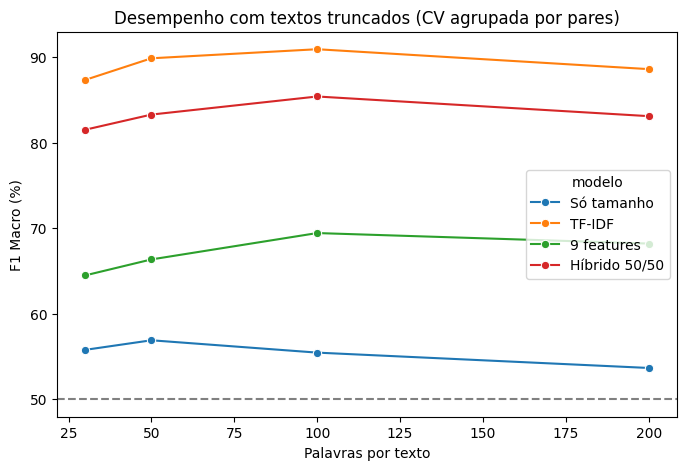

In [17]:
# Gráfico do F1 Macro por nível de truncamento (linha tracejada = acaso).
plt.figure(figsize=(8, 5))
sns.lineplot(data=res_trunc, x="N", y="f1_macro", hue="modelo", marker="o")
plt.axhline(50, ls="--", c="gray")
plt.xlabel("Palavras por texto")
plt.ylabel("F1 Macro (%)")
plt.title("Desempenho com textos truncados (CV agrupada por pares)")
plt.show()


In [18]:
# Monta o conjunto N=50 com e sem título (título = primeira linha do texto original).
def remover_titulo(texto):
    partes = re.split(r"\n", texto.strip(), maxsplit=1)
    return partes[1].strip() if len(partes) == 2 and partes[1].strip() else texto

df_modelo["text_sem_titulo"] = df_modelo["text"].apply(remover_titulo)
print("Textos em que um título foi removido:",
      (df_modelo["text_sem_titulo"] != df_modelo["text"]).mean().round(3))

d50 = montar_truncado(50)
d50 = d50.merge(df_modelo[["pair_id", "label", "text_sem_titulo"]], on=["pair_id", "label"])
d50["trunc_sem_titulo"] = d50["text_sem_titulo"].str.split().str[:50].str.join(" ")
d50 = d50[d50["text_sem_titulo"].str.split().str.len() >= 50]
d50 = d50[d50.groupby("pair_id")["label"].transform("nunique") == 2].reset_index(drop=True)
print("Pares mantidos:", d50["pair_id"].nunique())

Textos em que um título foi removido: 0.08
Pares mantidos: 3497


In [19]:
# Compara o TF-IDF com e sem título na mesma amostra e no mesmo protocolo.
def cv_tfidf(textos, yv, gv):
    acc, f1 = [], []
    for tr, te in cv_trunc.split(textos, yv, gv):
        mdl = novo_tfidf().fit(textos.iloc[tr], yv.iloc[tr])
        a, f = metr(yv.iloc[te], mdl.predict(textos.iloc[te]))
        acc.append(a); f1.append(f)
    return np.mean(acc) * 100, np.std(acc) * 100, np.mean(f1) * 100

comp_titulo = pd.DataFrame(
    [cv_tfidf(d50[c], d50["label"], d50["pair_id"]) for c in ["texto_trunc", "trunc_sem_titulo"]],
    index=["com título", "sem título"], columns=["acc", "acc_std", "f1_macro"]
)
display(comp_titulo.round(2))

,acc,acc_std,f1_macro
com título,89.66,0.85,89.66
sem título,88.78,0.99,88.77


In [20]:
# Exploratório: termos com maior peso para cada classe no TF-IDF de 50 palavras (com título), treinado em toda a amostra.
mdl_expl = novo_tfidf().fit(d50["texto_trunc"], d50["label"])
vocab = np.array(mdl_expl.named_steps["tfidf"].get_feature_names_out())
coefs = mdl_expl.named_steps["svm"].coef_[0]   # positivo = true, negativo = fake

ordem = np.argsort(coefs)
termos = pd.DataFrame({
    "FAKE (termo)": vocab[ordem[:30]], "peso_fake": coefs[ordem[:30]].round(3),
    "TRUE (termo)": vocab[ordem[::-1][:30]], "peso_true": coefs[ordem[::-1][:30]].round(3),
})
display(termos)

,FAKE (termo),peso_fake,TRUE (termo),peso_true
0,lula,-3.040,diz,3.625
1,hoje,-2.901,nesta,3.584
2,um,-2.680,em,2.889
3,dilma,-2.584,de,2.544
4,uma,-2.276,por,2.534
5,de acordo,-2.217,mas,2.351
6,está,-2.194,feira,2.335
7,acordo com,-2.027,como,2.115
8,poderá,-1.901,sobre,1.905
9,última,-1.593,ano,1.693


In [21]:
# Mede quantos textos de cada classe têm \n e \t literais (barra invertida + letra).
df_modelo["tem_escape"] = df_modelo["text"].str.contains(r"\\[nt]", regex=True)
df_modelo["qtd_escape"] = df_modelo["text"].str.count(r"\\[nt]")
display(df_modelo.groupby("label")[["tem_escape", "qtd_escape"]].mean().round(3))

,tem_escape,qtd_escape
label,,
fake,0.0,0.0
true,0.0,0.0


In [22]:
# Converte \n literal em quebra real e \t literal em espaço, em df e df_modelo.
def corrigir_escapes(s):
    return (s.str.replace(r"\\r\\n|\\n|\\r", "\n", regex=True)
             .str.replace(r"\\t", " ", regex=True)
             .str.replace(r"[ \t]+", " ", regex=True)
             .str.strip())

df["text"] = corrigir_escapes(df["text"])
df_modelo["text"] = corrigir_escapes(df_modelo["text"])
df_modelo["n_palavras_texto"] = df_modelo["text"].str.split().str.len()
df_modelo["text_sem_titulo"] = df_modelo["text"].apply(remover_titulo)

print("Escapes restantes:", df_modelo["text"].str.contains(r"\\[nt]", regex=True).sum())
display(df_modelo.groupby("label")["text_sem_titulo"].apply(
    lambda s: (s != df_modelo.loc[s.index, "text"]).mean()).round(3).rename("% com título removido"))


Escapes restantes: 0


,% com título removido
label,
fake,0.073
true,0.088


In [23]:
# Redefine título como a primeira frase do texto e mede quantas palavras ele ocupa por classe.
def remover_titulo(texto):
    partes = re.split(r"(?<=[.!?])\s+", texto.strip(), maxsplit=1)
    return partes[1].strip() if len(partes) == 2 and partes[1].strip() else texto

df_modelo["text_sem_titulo"] = df_modelo["text"].apply(remover_titulo)
df_modelo["palavras_titulo"] = (df_modelo["n_palavras_texto"]
                                - df_modelo["text_sem_titulo"].str.split().str.len())

display(df_modelo.groupby("label").agg(
    pct_com_titulo=("palavras_titulo", lambda s: (s > 0).mean() * 100),
    palavras_titulo_media=("palavras_titulo", "mean")
).round(2))

,pct_com_titulo,palavras_titulo_media
label,,
fake,100.0,11.71
true,100.0,19.21


In [24]:
# Compara o TF-IDF com e sem título na mesma amostra e no mesmo protocolo.
def cv_tfidf(textos, yv, gv):
    acc, f1 = [], []
    for tr, te in cv_trunc.split(textos, yv, gv):
        mdl = novo_tfidf().fit(textos.iloc[tr], yv.iloc[tr])
        a, f = metr(yv.iloc[te], mdl.predict(textos.iloc[te]))
        acc.append(a); f1.append(f)
    return np.mean(acc) * 100, np.std(acc) * 100, np.mean(f1) * 100

comp_titulo = pd.DataFrame(
    [cv_tfidf(d50[c], d50["label"], d50["pair_id"]) for c in ["texto_trunc", "trunc_sem_titulo"]],
    index=["com título", "sem título"], columns=["acc", "acc_std", "f1_macro"]
)
display(comp_titulo.round(2))

,acc,acc_std,f1_macro
com título,89.66,0.85,89.66
sem título,88.78,0.99,88.77


In [25]:
# Compara o TF-IDF com e sem a primeira frase na mesma amostra e no mesmo protocolo.
def cv_tfidf(textos, yv, gv):
    acc, f1 = [], []
    for tr, te in cv_trunc.split(textos, yv, gv):
        mdl = novo_tfidf().fit(textos.iloc[tr], yv.iloc[tr])
        a, f = metr(yv.iloc[te], mdl.predict(textos.iloc[te]))
        acc.append(a); f1.append(f)
    return np.mean(acc) * 100, np.std(acc) * 100, np.mean(f1) * 100

comp_titulo = pd.DataFrame(
    [cv_tfidf(d50[c], d50["label"], d50["pair_id"]) for c in ["texto_trunc", "trunc_sem_titulo"]],
    index=["com título", "sem título"], columns=["acc", "acc_std", "f1_macro"]
)
display(comp_titulo.round(2))

,acc,acc_std,f1_macro
com título,89.66,0.85,89.66
sem título,88.78,0.99,88.77


In [26]:
# Listas manuais de veículos e marcadores temporais usadas no mascaramento.
FONTES = {"g1", "globo", "folha", "estadão", "estadao", "uol", "veja", "band", "sbt",
          "record", "r7", "cnn", "reuters", "afp", "ansa", "bbc", "valor", "exame",
          "istoé", "época", "jovem pan", "agência", "agencia"}

TEMPORAIS = {"hoje", "ontem", "amanhã", "segunda", "terça", "quarta", "quinta", "sexta",
             "sábado", "domingo", "feira", "nesta", "neste", "desta", "deste", "nessa",
             "nesse", "dessa", "desse", "janeiro", "fevereiro", "março", "abril", "maio",
             "junho", "julho", "agosto", "setembro", "outubro", "novembro", "dezembro"}

In [27]:
# Gera as 4 versões mascaradas de cada texto em uma única passada do spaCy (NER precisa do texto com maiúsculas).
def mascarar(doc, nivel):
    out = []
    for t in doc:
        tl = t.text.lower()
        if nivel >= 1 and t.ent_type_ in {"PER", "ORG", "LOC", "MISC"}:
            if t.ent_iob_ == "B":
                out.append("ENT" + t.ent_type_ + t.whitespace_)
            elif t.whitespace_ and out:
                out[-1] = out[-1].rstrip() + " "
            continue
        if nivel >= 2 and (t.like_num or tl in FONTES):
            out.append(("NUM" if t.like_num else "FONTE") + t.whitespace_)
            continue
        if nivel >= 3 and tl in TEMPORAIS:
            out.append("TEMPO" + t.whitespace_)
            continue
        out.append(t.text_with_ws)
    return "".join(out)

docs50 = list(nlp.pipe(d50["texto_trunc"].tolist(), batch_size=64, disable=["parser"]))
for nivel, nome in enumerate(["A_original", "B_entidades", "C_ent_num_fonte", "D_mais_tempo"]):
    d50[nome] = [mascarar(doc, nivel) for doc in docs50]

print(d50.loc[0, "A_original"][:300], "\n")
print(d50.loc[0, "D_mais_tempo"][:300])


Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar. A senadora Kátia Abreu (sem partido-TO) disse que sua expulsão do PMDB foi resultado de uma ação da cúpula atual da legenda que, segundo ela, é oportunista. “Amanhã eu vou botar numa moldura dourada 

ENTPER diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar. A senadora ENTPER (sem partido-TO) disse que sua expulsão do ENTMISC foi resultado de uma ação da cúpula atual da legenda que, NUM ela, é oportunista. “ENTPER eu vou botar numa moldura dourada


In [28]:
# Exploratório: termos mais fortes de cada classe no nível D, para ver o que sobrou de sinal.
mdl_d = novo_tfidf().fit(d50["D_mais_tempo"], d50["label"])
vocab_d = np.array(mdl_d.named_steps["tfidf"].get_feature_names_out())
coef_d = mdl_d.named_steps["svm"].coef_[0]
ordem_d = np.argsort(coef_d)
display(pd.DataFrame({
    "FAKE (termo)": vocab_d[ordem_d[:30]], "peso_fake": coef_d[ordem_d[:30]].round(3),
    "TRUE (termo)": vocab_d[ordem_d[::-1][:30]], "peso_true": coef_d[ordem_d[::-1][:30]].round(3),
}))

,FAKE (termo),peso_fake,TRUE (termo),peso_true
0,tempo num,-2.980,diz,3.514
1,uma,-2.377,tempo tempo,3.241
2,entper,-2.270,feira,2.583
3,de acordo,-2.240,por,2.526
4,acordo com,-2.164,de,2.523
5,dilma,-1.981,feira num,2.500
6,está,-1.922,mas,2.448
7,poderá,-1.872,em,2.407
8,senado,-1.760,tempo,2.394
9,cidade de,-1.679,como,2.153


In [29]:
# Gera os níveis E, F e G a partir dos docs50 já processados e avalia todas as versões (A a G).
POLITICOS = {
    "pt", "psdb", "pmdb", "mdb", "psol", "psl", "dem", "pcdob", "petista", "petistas",
    "tucano", "tucanos", "peemedebista", "comunista", "comunistas", "esquerda", "direita",
    "esquerdista", "esquerdistas", "socialista", "bolsonarista", "lulista", "senado",
    "senador", "senadora", "senadores", "deputado", "deputada", "deputados", "câmara",
    "stf", "tse", "tcu", "ministro", "ministra", "presidente", "presidenta", "governo",
    "planalto", "congresso", "impeachment", "lava", "jato", "corrupção", "propina",
    "reforma", "previdência"
}
FUNCIONAIS = {"ADP", "DET", "PRON", "CCONJ", "SCONJ", "AUX", "PART"}

def nivel_E(doc):
    out = []
    for t in doc:
        tl = t.text.lower()
        if t.ent_type_ in {"PER", "ORG", "LOC", "MISC"} or t.pos_ == "PROPN":
            tok = "ENT"
        elif t.like_num:
            tok = "NUM"
        elif tl in FONTES:
            tok = "FONTE"
        elif tl in TEMPORAIS:
            tok = "TEMPO"
        elif tl in POLITICOS:
            tok = "POL"
        else:
            out.append(t.text_with_ws); continue
        out.append(tok + t.whitespace_)
    return "".join(out)

def nivel_F(doc):
    return "".join(
        t.text_with_ws if (t.is_punct or t.is_stop or t.pos_ in FUNCIONAIS)
        else t.pos_ + t.whitespace_
        for t in doc
    )

def nivel_G(doc):
    return " ".join(t.pos_ for t in doc if not t.is_space)

d50["E_reforcado"] = [nivel_E(doc) for doc in docs50]
d50["F_funcionais"] = [nivel_F(doc) for doc in docs50]
d50["G_so_pos"] = [nivel_G(doc) for doc in docs50]

for col in ["E_reforcado", "F_funcionais", "G_so_pos"]:
    print(f"{col}:\n{d50.loc[0, col][:250]}\n")

versoes = ["A_original", "B_entidades", "C_ent_num_fonte", "D_mais_tempo",
           "E_reforcado", "F_funcionais", "G_so_pos"]
comp_estilo = pd.DataFrame(
    [cv_tfidf(d50[v], d50["label"], d50["pair_id"]) for v in versoes],
    index=versoes, columns=["acc", "acc_std", "f1_macro"]
)
comp_estilo["queda_vs_A"] = comp_estilo["f1_macro"] - comp_estilo.loc["A_original", "f1_macro"]
display(comp_estilo.round(2))

E_reforcado:
ENT ENT diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar. A POL ENT ENT (sem ENT) disse que sua expulsão do ENT foi resultado de uma ação da cúpula atual da legenda que, NUM ela, é oportunista. ENTENT eu vou botar numa moldur

F_funcionais:
PROPN PROPN diz que vai VERB sua NOUN em uma NOUN, mas não para de VERB. A NOUN PROPN PROPN (sem PROPN) VERB que sua NOUN do PROPN foi NOUN de uma NOUN da NOUN ADJ da NOUN que, segundo ela, é ADJ. “ADV eu vou VERB numa NOUN VERB

G_so_pos:
PROPN PROPN VERB SCONJ AUX VERB DET NOUN ADP DET NOUN PUNCT CCONJ ADV SCONJ SCONJ VERB PUNCT DET NOUN PROPN PROPN PUNCT ADP PROPN PUNCT VERB SCONJ DET NOUN ADP PROPN AUX NOUN ADP DET NOUN ADP NOUN ADJ ADP NOUN SCONJ PUNCT ADP PRON PUNCT AUX ADJ PUNCT



,acc,acc_std,f1_macro,queda_vs_A
A_original,89.66,0.85,89.66,0.00
B_entidades,88.18,0.41,88.17,-1.49
C_ent_num_fonte,87.80,0.64,87.80,-1.86
D_mais_tempo,87.22,0.91,87.21,-2.45
E_reforcado,87.56,0.91,87.55,-2.11
F_funcionais,82.17,1.07,82.17,-7.49
G_so_pos,79.83,0.93,79.82,-9.84


In [30]:
# Extrai o domínio de cada notícia a partir do link e conta quantas notícias cada domínio tem por classe.
df_modelo["dominio"] = (df_modelo["link"].astype(str)
                        .str.extract(r"https?://(?:www\.)?([^/]+)")[0]
                        .str.lower())

inventario = (df_modelo.groupby(["label", "dominio"]).size()
              .rename("n").reset_index()
              .sort_values(["label", "n"], ascending=[True, False]))

print("Domínios distintos por classe:")
display(inventario.groupby("label")["dominio"].nunique())
for lab in ["fake", "true"]:
    print(f"\n{lab.upper()} — maiores domínios")
    display(inventario[inventario["label"] == lab].head(10))

Domínios distintos por classe:


,dominio
label,
fake,5
true,24



FAKE — maiores domínios


,label,dominio,n
2,fake,diariodobrasil.org,3337
0,fake,afolhabrasil.com.br,173
3,fake,thejornalbrasil.com.br,66
1,fake,ceticismopolitico.com,16
4,fake,topfivetv.com,7



TRUE — maiores domínios


,label,dominio,n
18,true,g1.globo.com,2299
22,true,politica.estadao.com.br,753
19,true,internacional.estadao.com.br,114
10,true,cultura.estadao.com.br,95
28,true,www1.folha.uol.com.br,91
12,true,economia.estadao.com.br,51
8,true,brasil.estadao.com.br,46
15,true,esportes.estadao.com.br,30
6,true,alias.estadao.com.br,29
23,true,sao-paulo.estadao.com.br,16


In [31]:
# Agrupa subdomínios em veículos (afolhabrasil é checado antes de folha para não confundir) e leva a informação para d50.
def veiculo(dom):
    for chave in ["diariodobrasil", "afolhabrasil", "thejornalbrasil", "ceticismopolitico",
                  "topfivetv", "g1.globo", "estadao", "folha"]:
        if chave in dom:
            return chave.split(".")[0]
    return "outros_true"

df_modelo["veiculo"] = df_modelo["dominio"].fillna("").apply(veiculo)
display(df_modelo.groupby(["label", "veiculo"]).size().rename("n").to_frame())

d50 = d50.drop(columns=["veiculo"], errors="ignore").merge(
    df_modelo[["pair_id", "label", "veiculo"]], on=["pair_id", "label"])

n
label veiculo                
fake  afolhabrasil        173
      ceticismopolitico    16
      diariodobrasil     3337
      thejornalbrasil      66
      topfivetv             7
true  estadao            1203
      folha                95
      g1                 2299
      outros_true           2

In [32]:
# Treino: pares 100% Diário do Brasil + G1. Teste: textos de fontes nunca vistas (sem pares divididos).
FONTES_TREINO = {"diariodobrasil", "g1"}
d50["na_fonte_treino"] = d50["veiculo"].isin(FONTES_TREINO)
par_todo_treino = d50.groupby("pair_id")["na_fonte_treino"].transform("all")

treino_fonte = d50[par_todo_treino].reset_index(drop=True)
teste_fonte = d50[~d50["na_fonte_treino"]].reset_index(drop=True)

print("Pares no treino:", treino_fonte["pair_id"].nunique())
display(teste_fonte.groupby(["label", "veiculo"]).size().rename("n_teste").to_frame())

Pares no treino: 2126


n_teste
label veiculo                   
fake  afolhabrasil           171
      ceticismopolitico       16
      thejornalbrasil         65
      topfivetv                7
true  estadao               1185
      folha                   94
      outros_true              2

In [33]:
# Para cada representação: F1 dentro das fontes de treino (CV) vs desempenho em fontes nunca vistas.
from sklearn.metrics import recall_score, balanced_accuracy_score

versoes_fonte = ["A_original", "E_reforcado", "F_funcionais", "G_so_pos"]
linhas = []
for v in versoes_fonte:
    _, _, f1_mesma = cv_tfidf(treino_fonte[v], treino_fonte["label"], treino_fonte["pair_id"])
    mdl = novo_tfidf().fit(treino_fonte[v], treino_fonte["label"])
    pred = mdl.predict(teste_fonte[v])
    teste_fonte[f"acerto_{v}"] = (pred == teste_fonte["label"])
    yt = teste_fonte["label"]
    linhas.append({
        "versao": v,
        "f1_mesma_fonte": f1_mesma,
        "bal_acc_fonte_nova": balanced_accuracy_score(yt, pred) * 100,
        "recall_fake_fonte_nova": recall_score(yt, pred, pos_label="fake") * 100,
        "recall_true_fonte_nova": recall_score(yt, pred, pos_label="true") * 100,
    })

res_fonte = pd.DataFrame(linhas).set_index("versao")
display(res_fonte.round(2))

,f1_mesma_fonte,bal_acc_fonte_nova,recall_fake_fonte_nova,recall_true_fonte_nova
versao,,,,
A_original,90.71,74.34,74.90,73.77
E_reforcado,89.41,71.86,71.81,71.90
F_funcionais,84.90,68.06,73.36,62.76
G_so_pos,83.23,64.24,65.25,63.23


In [34]:
# Taxa de acerto por veículo nunca visto, para cada representação.
acerto_veiculo = (teste_fonte.groupby(["label", "veiculo"])
                  [[f"acerto_{v}" for v in versoes_fonte]].mean().mul(100).round(1))
acerto_veiculo["n"] = teste_fonte.groupby(["label", "veiculo"]).size()
display(acerto_veiculo)

acerto_A_original  acerto_E_reforcado  \
label veiculo                                                    
fake  afolhabrasil                    77.2                76.6   
      ceticismopolitico               62.5                62.5   
      thejornalbrasil                 72.3                63.1   
      topfivetv                       71.4                57.1   
true  estadao                         73.2                71.3   
      folha                           81.9                79.8   
      outros_true                     50.0                50.0   

                         acerto_F_funcionais  acerto_G_so_pos     n  
label veiculo                                                        
fake  afolhabrasil                      72.5             69.0   171  
      ceticismopolitico                 75.0             62.5    16  
      thejornalbrasil                   76.9             53.8    65  
      topfivetv                         57.1             85.7     7  
true  estadao                           61.1             63.0  1185  
      folha                             83.0             66.0    94  
      outros_true                      100.0            100.0     2

In [35]:
# Extrai as 9 features dos textos truncados de treino e teste do split por fonte.
from sklearn.linear_model import LogisticRegression

X_feat_tr = extrair_features(treino_fonte["texto_trunc"].tolist())
X_feat_te = extrair_features(teste_fonte["texto_trunc"].tolist())
ytr, gtr, yte = treino_fonte["label"], treino_fonte["pair_id"], teste_fonte["label"]
Xtxt_tr, Xtxt_te = treino_fonte["A_original"], teste_fonte["A_original"]

In [36]:
# Treina TF-IDF e features no treino; pesos da fusão vêm de scores out-of-fold do próprio treino.
m_tf = novo_tfidf().fit(Xtxt_tr, ytr)
m_ft = novo_features().fit(X_feat_tr, ytr)

oof = np.column_stack([
    cross_val_predict(novo_tfidf(), Xtxt_tr, ytr, groups=gtr, cv=cv_interno, method="decision_function"),
    cross_val_predict(novo_features(), X_feat_tr, ytr, groups=gtr, cv=cv_interno, method="decision_function"),
])
sc_scores = StandardScaler().fit(oof)
stack = LogisticRegression().fit(sc_scores.transform(oof), ytr)

S_te = sc_scores.transform(np.column_stack([
    m_tf.decision_function(Xtxt_te), m_ft.decision_function(X_feat_te)
]))

preds_fonte = {
    "TF-IDF": m_tf.predict(Xtxt_te),
    "9 features": m_ft.predict(X_feat_te),
    "Híbrido 50/50": np.where(S_te.mean(axis=1) >= 0, "true", "fake"),
    "Stacking (pesos do treino)": stack.predict(S_te),
}

res_modelos_fonte = pd.DataFrame([{
    "modelo": nome,
    "bal_acc_fonte_nova": balanced_accuracy_score(yte, p) * 100,
    "recall_fake": recall_score(yte, p, pos_label="fake") * 100,
    "recall_true": recall_score(yte, p, pos_label="true") * 100,
} for nome, p in preds_fonte.items()]).set_index("modelo")
display(res_modelos_fonte.round(2))

print("Pesos aprendidos pelo stacking [TF-IDF, features]:", stack.coef_[0].round(3))

,bal_acc_fonte_nova,recall_fake,recall_true
modelo,,,
TF-IDF,74.34,74.90,73.77
9 features,62.57,64.09,61.05
Híbrido 50/50,70.02,72.59,67.45
Stacking (pesos do treino),74.32,77.99,70.65


Pesos aprendidos pelo stacking [TF-IDF, features]: [4.267 0.225]


In [37]:
# Grid de hiperparâmetros avaliado por balanced accuracy em fontes nunca vistas (validação por fonte).
from itertools import product

representacoes = {
    "word (1,1)": dict(analyzer="word", ngram_range=(1, 1)),
    "word (1,2)": dict(analyzer="word", ngram_range=(1, 2)),
    "word (1,3)": dict(analyzer="word", ngram_range=(1, 3)),
    "char_wb (3,5)": dict(analyzer="char_wb", ngram_range=(3, 5)),
}
grid = []
for (nome_rep, rep), C, min_df, sublinear in product(representacoes.items(), [0.1, 1, 10], [1, 3], [False, True]):
    mdl = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, min_df=min_df, sublinear_tf=sublinear,
                                  dtype=np.float32, **rep)),
        ("svm", LinearSVC(C=C, max_iter=20000))
    ]).fit(Xtxt_tr, ytr)
    p = mdl.predict(Xtxt_te)
    grid.append({"repr": nome_rep, "C": C, "min_df": min_df, "sublinear": sublinear,
                 "bal_acc": balanced_accuracy_score(yte, p) * 100,
                 "recall_fake": recall_score(yte, p, pos_label="fake") * 100,
                 "recall_true": recall_score(yte, p, pos_label="true") * 100})

res_grid = pd.DataFrame(grid).sort_values("bal_acc", ascending=False)
display(res_grid.head(10).round(2))
display(res_grid.groupby("repr")["bal_acc"].agg(["mean", "max"]).round(2))
display(res_grid.groupby("C")["bal_acc"].agg(["mean", "max"]).round(2))

,repr,C,min_df,sublinear,bal_acc,recall_fake,recall_true
32,"word (1,3)",10.0,1,False,74.80,75.29,74.32
20,"word (1,2)",10.0,1,False,74.80,75.68,73.93
4,"word (1,1)",1.0,1,False,74.74,79.15,70.34
28,"word (1,3)",1.0,1,False,74.73,74.90,74.55
34,"word (1,3)",10.0,3,False,74.68,76.45,72.91
30,"word (1,3)",1.0,3,False,74.49,75.68,73.30
22,"word (1,2)",10.0,3,False,74.40,76.83,71.98
16,"word (1,2)",1.0,1,False,74.34,74.90,73.77
18,"word (1,2)",1.0,3,False,74.10,76.06,72.13
36,"char_wb (3,5)",0.1,1,False,73.74,76.83,70.65


,mean,max
repr,,
"char_wb (3,5)",72.10,73.74
"word (1,1)",72.64,74.74
"word (1,2)",73.10,74.80
"word (1,3)",72.99,74.80


,mean,max
C,,
0.1,72.18,73.74
1.0,73.18,74.74
10.0,72.76,74.80


In [38]:
# Monta treino (pares 100% Diário do Brasil + G1) e teste (fontes nunca vistas) a partir do df_modelo completo.
base_fonte = df_modelo[["text", "label", "pair_id", "veiculo", "n_palavras_texto"]].copy()
base_fonte["na_treino"] = base_fonte["veiculo"].isin(FONTES_TREINO)
par_ok = base_fonte.groupby("pair_id")["na_treino"].transform("all")
tr_base = base_fonte[par_ok].reset_index(drop=True)
te_base = base_fonte[~base_fonte["na_treino"]].reset_index(drop=True)

def truncar(s, N):
    return s.str.split().str[:N].str.join(" ")

esquemas = {
    "treino N=50": (truncar(tr_base["text"], 50), tr_base["label"]),
    "treino misto 30/50/100": (
        pd.concat([truncar(tr_base["text"], n) for n in (30, 50, 100)], ignore_index=True),
        pd.concat([tr_base["label"]] * 3, ignore_index=True)),
    "treino texto completo": (tr_base["text"], tr_base["label"]),
}
print("Pares no treino:", tr_base["pair_id"].nunique(), "| Textos de teste:", len(te_base))

Pares no treino: 2208 | Textos de teste: 1562


In [39]:
# Treina cada esquema uma vez e testa em fontes novas com 30, 50 e 100 palavras.
linhas = []
for nome, (Xtr_e, ytr_e) in esquemas.items():
    mdl = novo_tfidf().fit(Xtr_e, ytr_e)
    for N in (30, 50, 100):
        t = te_base[te_base["n_palavras_texto"] >= N]
        p = mdl.predict(truncar(t["text"], N))
        linhas.append({"esquema": nome, "N_teste": N, "n_teste": len(t),
                       "bal_acc": balanced_accuracy_score(t["label"], p) * 100,
                       "recall_fake": recall_score(t["label"], p, pos_label="fake") * 100,
                       "recall_true": recall_score(t["label"], p, pos_label="true") * 100})

res_len = pd.DataFrame(linhas)
display(res_len.pivot(index="esquema", columns="N_teste", values="bal_acc").round(2))
display(res_len.round(2))

N_teste,30,50,100
esquema,,,
treino N=50,73.04,74.67,68.58
treino misto 30/50/100,73.81,75.54,70.14
treino texto completo,50.08,50.35,51.72


,esquema,N_teste,n_teste,bal_acc,recall_fake,recall_true
0,treino N=50,30,1562,73.04,78.63,67.46
1,treino N=50,50,1562,74.67,74.81,74.54
2,treino N=50,100,1544,68.58,59.18,77.98
3,treino misto 30/50/100,30,1562,73.81,79.39,68.23
4,treino misto 30/50/100,50,1562,75.54,78.63,72.46
5,treino misto 30/50/100,100,1544,70.14,66.53,73.75
6,treino texto completo,30,1562,50.08,100.00,0.15
7,treino texto completo,50,1562,50.35,100.00,0.69
8,treino texto completo,100,1544,51.72,99.59,3.85


In [40]:
# Treina o modelo final com todo o Fake.br, usando truncamento misto em 30, 50 e 100 palavras.
X_final = pd.concat([truncar(df_modelo["text"], n) for n in (30, 50, 100)], ignore_index=True)
y_final = pd.concat([df_modelo["label"]] * 3, ignore_index=True)

modelo_final = novo_tfidf().fit(X_final, y_final)
print("Textos de treino (com aumento):", len(X_final))

Textos de treino (com aumento): 21594


In [41]:
# Função de classificação no formato do produto: corta a entrada em até 50 palavras e retorna label e score.
def classificar(texto, N=50):
    trecho = " ".join(str(texto).split()[:N])
    score = float(modelo_final.decision_function([trecho])[0])
    return ("true" if score >= 0 else "fake"), round(score, 3)

print(classificar("O Supremo Tribunal Federal realizou nesta terça-feira uma sessão extraordinária para analisar o pedido."))
print(classificar("URGENTE!!! Compartilhem antes que apaguem, o governo vai confiscar a poupança de todos amanhã."))

('true', 1.611)
('fake', -1.261)


In [42]:
# Salva o modelo treinado e faz o download para uso no produto.
import joblib
joblib.dump(modelo_final, "modelo_final_tfidf.joblib")
files.download("modelo_final_tfidf.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
# Carrega o FakeRecogna 2.0 (versão com resumo abstrativo das true) direto do Hugging Face.
!pip install -q datasets
from datasets import load_dataset

ds_rec2 = load_dataset("recogna-nlp/fakerecogna2-abstrativa")
print(ds_rec2)
df_rec2 = pd.concat([ds_rec2[s].to_pandas() for s in ds_rec2.keys()], ignore_index=True)
print("Shape:", df_rec2.shape)
print("Colunas:", df_rec2.columns.tolist())
display(df_rec2.head(3))

README.md:   0%|          | 0.00/4.99k [00:00<?, ?B/s]

fakerecogna_abstrativo.csv: reconstructing file:   0%|          |  0.00B / 42.3MB            

fakerecogna_abstrativo.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/52800 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'Titulo', 'Categoria', 'Autor', 'Data', 'URL', 'Noticia', 'Label', 'Subtitulo'],
        num_rows: 52800
    })
})
Shape: (52800, 9)
Colunas: ['Unnamed: 0', 'Titulo', 'Categoria', 'Autor', 'Data', 'URL', 'Noticia', 'Label', 'Subtitulo']


,Unnamed: 0,Titulo,Categoria,Autor,Data,URL,Noticia,Label,Subtitulo
0,8424,GO: PM que prendeu petista que exibia faixa 'B...,política,Beatriz Gomes,01/06/2021 13h40Atualizada em 01/06/2021 14h32,None,a ssp (secretaria de segurança pública) do est...,0,None
1,18785,Bolsonaristas criticam aglomeração; esquerda c...,política,29/05/2021 13h37Atualizada em 30/05/2021 00h16,29/05/2021 13h37Atualizada em 30/05/2021 00h16,None,protestos realizados hoje por grupos de esquer...,0,None
2,43823,É #FAKE que Lula foi autorizado a dar entrevis...,None,"Por Adriane Schultz, G1",22/10/2018 16h40,https://g1.globo.com/fato-ou-fake/noticia/2018...,circula nas redes sociais uma mensagem que diz...,1,Mensagem que viralizou no WhatsApp é falsa. Mi...


In [44]:
# Identifica colunas de label e texto, mostra a distribuição e 3 exemplos de cada classe.
col_label_r2 = [c for c in df_rec2.columns if c.lower() in ("label", "classe", "class")][0]
col_texto_r2 = max(
    [c for c in df_rec2.columns if df_rec2[c].dtype == object],
    key=lambda c: df_rec2[c].astype(str).str.len().mean()
)
print("Label:", col_label_r2, "| Texto:", col_texto_r2)
display(df_rec2[col_label_r2].value_counts(dropna=False))

for lab in df_rec2[col_label_r2].dropna().unique():
    print(f"\n===== {lab} =====")
    amostra_r2 = df_rec2[df_rec2[col_label_r2] == lab][col_texto_r2].dropna()
    for t in amostra_r2.sample(min(3, len(amostra_r2)), random_state=SEED):
        print("-", str(t)[:500].replace("\n", " "), "\n")

Label: Label | Texto: Noticia


,count
Label,
0,26400
1,26400



===== 0 =====
- a união federal foi condenada a pagar uma indenização de r$50 mil por uma fala do ex-ministro abraham weintraub sobre as universidades públicas brasileiras. a ação coletiva foi movida pela une (união nacional dos estudantes). a juíza silvia figueiredo marques ressaltou o viés ideológico do ex ministro e afirmou que ele não apresentou provas de suas acusações: a vítima foi a coletividade dos estudantes. o ministro não expressou preocupação com o consumo e tráfico de drogas nas universidades, mas  

- o estado de 55 clínicas e centros de saúde em beirute, entre eles três dos mais importantes, não funcionam, alertou o diretor regional de emergências da instituição nesta quarta-feira (12), richard brennan, uma semana depois da explosão da capital do líbano. após avaliar o estado de 56 clínicas, centros de hospitais na capital libanesa, o diretor disse que pouco mais do que 50% não funcionam. em uma coletiva de imprensa virtual no cairo, ele disse que três dos principais ho

In [45]:
# Mede vocabulário de checagem e tamanho dos textos por classe.
marcadores = r"\b(fake|falso|falsa|boato|checagem|verifica|enganos[oa]|desmentid[oa]|viraliz\w*|circula\w*|mentira)\b"
df_rec2["tem_checagem"] = df_rec2[col_texto_r2].astype(str).str.lower().str.contains(marcadores, regex=True)
df_rec2["n_palavras"] = df_rec2[col_texto_r2].astype(str).str.split().str.len()

display(df_rec2.groupby(col_label_r2).agg(
    pct_checagem=("tem_checagem", lambda s: s.mean() * 100),
    palavras_mediana=("n_palavras", "median"),
    palavras_p25=("n_palavras", lambda s: s.quantile(0.25)),
    palavras_p75=("n_palavras", lambda s: s.quantile(0.75)),
).round(1))

/tmp/ipykernel_1308/1572644425.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_rec2["tem_checagem"] = df_rec2[col_texto_r2].astype(str).str.lower().str.contains(marcadores, regex=True)


,pct_checagem,palavras_mediana,palavras_p25,palavras_p75
Label,,,,
0,3.5,95.0,75.0,115.0
1,26.9,50.0,23.0,86.0


In [46]:
# Converte labels (1 = fake, 0 = true), extrai o boato entre aspas e classifica o tipo de cada texto.
df_rec2["label"] = df_rec2["Label"].map({1: "fake", 0: "true"})
txt_r2 = df_rec2["Noticia"].astype(str).str.strip()
df_rec2["rumor_citado"] = txt_r2.str.extract(r'^[“"](.+?)[”"]')[0]
n_pal_citado = df_rec2["rumor_citado"].str.split().str.len().fillna(0)

df_rec2["tipo"] = np.select(
    [df_rec2["label"] == "true",
     n_pal_citado >= 20,
     df_rec2["tem_checagem"]],
    ["true_resumida", "fake_boato_citado", "fake_texto_checagem"],
    default="fake_outros"
)
display(df_rec2["tipo"].value_counts())

for tp in ["fake_boato_citado", "fake_outros"]:
    print(f"\n===== {tp} =====")
    col = "rumor_citado" if tp == "fake_boato_citado" else "Noticia"
    for t in df_rec2[df_rec2["tipo"] == tp][col].sample(3, random_state=SEED):
        print("-", str(t)[:300], "\n")

,count
tipo,
true_resumida,26400
fake_outros,17612
fake_texto_checagem,6630
fake_boato_citado,2158



===== fake_boato_citado =====
- presidente eleito, luiz inácio lula da silva, tem plano de criar nova cpmf que vai tributar todas as transações do pix, de congelar a poupança dos brasileiros, liberar apenas r$ 500 para o uso das famílias e de criar a moeda ‘peso real’ junto com argentina e venezuela 

- estes chineses são demais.! isto é uma boneca. esta é uma boneca android fabricada na china. é tão real – o que a próxima china fará 

- seria o covid-19 terrorismo chinês para desestabilizar a economia ocidental???? na austrália dentro de um shopping uma chinesa é presa após ser flagrada espirrando ou cuspindo nas bananas e comida. a quem interessa espalhar o coronavirus 


===== fake_outros =====
- [médicos cubanos que integravam o mais médicos chegaram ao brasil] sem nenhuma comprovação profissional - jair bolsonaro 

- atacadão dá vale-presente para quem compartilhar link no whatsapp durante a black friday 

- “carta da filha de billy graham” a filha de billy graham estava sendo en

In [47]:
# Avalia o modelo final, sem ajuste, no formato do produto (até 50 palavras): % previsto como fake por tipo.
df_rec2["texto_eval"] = np.where(df_rec2["tipo"] == "fake_boato_citado", df_rec2["rumor_citado"], txt_r2)
df_rec2["texto_eval"] = truncar(pd.Series(df_rec2["texto_eval"], index=df_rec2.index), 50)
df_rec2["n_pal_eval"] = df_rec2["texto_eval"].str.split().str.len()
df_rec2["pred"] = modelo_final.predict(df_rec2["texto_eval"])

res_r2 = df_rec2.groupby("tipo").agg(
    n=("pred", "size"),
    pct_prev_fake=("pred", lambda s: (s == "fake").mean() * 100),
    palavras_mediana=("n_pal_eval", "median"),
).round(1)
display(res_r2)

rec_true = (df_rec2.loc[df_rec2["tipo"] == "true_resumida", "pred"] == "true").mean()
rec_fake = (df_rec2.loc[df_rec2["tipo"] == "fake_boato_citado", "pred"] == "fake").mean()
print(f"Principal (true resumida x boato citado): recall true {rec_true*100:.1f}% | "
      f"recall fake {rec_fake*100:.1f}% | balanced acc {(rec_true + rec_fake)/2*100:.1f}%")

,n,pct_prev_fake,palavras_mediana
tipo,,,
fake_boato_citado,2158,69.5,36.0
fake_outros,17612,63.4,40.0
fake_texto_checagem,6630,58.5,50.0
true_resumida,26400,30.1,50.0


Principal (true resumida x boato citado): recall true 69.9% | recall fake 69.5% | balanced acc 69.7%


In [48]:
# Mesmo resultado separado por faixa de tamanho, para ver o efeito do comprimento da entrada.
df_rec2["faixa"] = pd.cut(df_rec2["n_pal_eval"], bins=[0, 19, 29, 49, 50],
                          labels=["<20", "20-29", "30-49", "50"])
display(df_rec2[df_rec2["tipo"].isin(["true_resumida", "fake_boato_citado"])]
        .groupby(["tipo", "faixa"], observed=True)["pred"]
        .agg(n="size", pct_prev_fake=lambda s: (s == "fake").mean() * 100).round(1))


n  pct_prev_fake
tipo              faixa                      
fake_boato_citado 20-29    747           68.5
                  30-49    801           68.0
                  50       610           72.6
true_resumida     <20      174           44.3
                  20-29    272           36.4
                  30-49   1309           34.6
                  50     24645           29.6

In [49]:
# Extrai o ano de cada texto (da coluna Data e, se faltar, da URL) e cruza com o tipo de texto.
data_txt = df_rec2["Data"].astype(str).str.extract(r"(\d{2}/\d{2}/\d{4})")[0]
df_rec2["ano"] = pd.to_datetime(data_txt, format="%d/%m/%Y", errors="coerce").dt.year
url_ano = df_rec2["URL"].astype(str).str.extract(r"/(20\d{2})/")[0].astype(float)
df_rec2["ano"] = df_rec2["ano"].fillna(url_ano)

print("Sem ano identificado:", df_rec2["ano"].isna().mean().round(3))
display(pd.crosstab(df_rec2["ano"].fillna(0).astype(int), df_rec2["tipo"]))

Sem ano identificado: 0.184


tipo,fake_boato_citado,fake_outros,fake_texto_checagem,true_resumida
ano,,,,
0,1002,5879,1569,1280
2013,0,14,5,0
2014,9,144,58,0
2015,0,106,38,0
2016,0,477,8,0
2017,19,1079,155,0
2018,58,1541,536,0
2019,131,1918,583,24
2020,270,2060,1119,10906


In [50]:
# Mostra as agências de origem das fake (domínio da URL), para avaliar a diversidade real de fontes.
df_rec2["dominio"] = (df_rec2["URL"].astype(str)
                      .str.extract(r"https?://(?:www\.)?([^/]+)")[0].str.lower())
display(df_rec2[df_rec2["label"] == "fake"]["dominio"].value_counts(dropna=False).head(15))

,count
dominio,
boatos.org,8579
e-farsas.com,3327
lupa.uol.com.br,3140
aosfatos.org,2656
noticias.uol.com.br,2567
g1.globo.com,2265
checamos.afp.com,1586
politica.estadao.com.br,1301
projetocomprova.com.br,877


In [51]:
# Prepara o FakeRecogna por ano: boato entre aspas quando existir; demais textos usam a notícia inteira.
df_rec2["texto_base"] = np.where(df_rec2["tipo"] == "fake_boato_citado", df_rec2["rumor_citado"], txt_r2)
fr20 = df_rec2[df_rec2["ano"] == 2020]
fr21 = df_rec2[df_rec2["ano"] == 2021]

fr20_fake = fr20[fr20["tipo"].isin(["fake_boato_citado", "fake_outros"])]
fr20_true = fr20[fr20["tipo"] == "true_resumida"].sample(len(fr20_fake), random_state=SEED)
print("FakeRecogna 2020 no treino -> fake:", len(fr20_fake), "| true:", len(fr20_true))

FakeRecogna 2020 no treino -> fake: 2330 | true: 2330


In [52]:
# Funções auxiliares: aumento com truncamento misto e modelo com class_weight balanceado.
def aumentar(textos, labels):
    t, l = pd.Series(list(textos)), pd.Series(list(labels))
    return (pd.concat([truncar(t, n) for n in (30, 50, 100)], ignore_index=True),
            pd.concat([l] * 3, ignore_index=True))

def novo_tfidf_bal():
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), dtype=np.float32)),
        ("svm", LinearSVC(C=1.0, max_iter=20000, class_weight="balanced"))
    ])

def avaliar_par(t_true, t_fake, mdl):
    p_t = mdl.predict(truncar(pd.Series(list(t_true)), 50))
    p_f = mdl.predict(truncar(pd.Series(list(t_fake)), 50))
    rt, rf = (p_t == "true").mean() * 100, (p_f == "fake").mean() * 100
    return rt, rf, (rt + rf) / 2

In [53]:
# Treina as 3 variantes e avalia em FakeRecogna 2021 (não visto) e nas fontes novas do Fake.br (controle).
variantes = {
    "Base: só Fake.br": (tr_base["text"], tr_base["label"]),
    "V1: + FR2020 fake e true": (
        pd.concat([tr_base["text"], fr20_fake["texto_base"], fr20_true["texto_base"]]),
        pd.concat([tr_base["label"], fr20_fake["label"], fr20_true["label"]])),
    "V2: + FR2020 só fake": (
        pd.concat([tr_base["text"], fr20_fake["texto_base"]]),
        pd.concat([tr_base["label"], fr20_fake["label"]])),
}

true21 = fr21[fr21["tipo"] == "true_resumida"]["texto_base"]
te50 = te_base[te_base["n_palavras_texto"] >= 50]
testes = {
    "FR2021 boato citado": (true21, fr21[fr21["tipo"] == "fake_boato_citado"]["texto_base"]),
    "FR2021 fake outros": (true21, fr21[fr21["tipo"] == "fake_outros"]["texto_base"]),
    "Fake.br fontes novas": (te50[te50["label"] == "true"]["text"], te50[te50["label"] == "fake"]["text"]),
}

linhas = []
for nv, (X, yv) in variantes.items():
    Xa, ya = aumentar(X, yv)
    mdl = novo_tfidf_bal().fit(Xa, ya)
    for nt, (tt, tf) in testes.items():
        rt, rf, b = avaliar_par(tt, tf, mdl)
        linhas.append({"variante": nv, "teste": nt, "recall_true": rt, "recall_fake": rf, "bal_acc": b})
    chk = mdl.predict(truncar(pd.Series(list(fr21[fr21["tipo"] == "fake_texto_checagem"]["texto_base"])), 50))
    linhas.append({"variante": nv, "teste": "FR2021 checagem (% prev. fake)",
                   "recall_fake": (chk == "fake").mean() * 100})
    print(nv, "concluída")

res_comb = pd.DataFrame(linhas)
display(res_comb.pivot(index="variante", columns="teste", values="bal_acc").round(2))
display(res_comb.round(2))

Base: só Fake.br concluída
V1: + FR2020 fake e true concluída
V2: + FR2020 só fake concluída


teste,FR2021 boato citado,FR2021 checagem (% prev. fake),FR2021 fake outros,Fake.br fontes novas
variante,,,,
Base: só Fake.br,69.16,NaN,66.48,75.54
V1: + FR2020 fake e true,83.08,NaN,82.12,75.48
V2: + FR2020 só fake,59.73,NaN,59.51,73.48


,variante,teste,recall_true,recall_fake,bal_acc
0,Base: só Fake.br,FR2021 boato citado,64.38,73.95,69.16
1,Base: só Fake.br,FR2021 fake outros,64.38,68.58,66.48
2,Base: só Fake.br,Fake.br fontes novas,72.46,78.63,75.54
3,Base: só Fake.br,FR2021 checagem (% prev. fake),NaN,61.81,NaN
4,V1: + FR2020 fake e true,FR2021 boato citado,85.48,80.67,83.08
5,V1: + FR2020 fake e true,FR2021 fake outros,85.48,78.75,82.12
6,V1: + FR2020 fake e true,Fake.br fontes novas,75.38,75.57,75.48
7,V1: + FR2020 fake e true,FR2021 checagem (% prev. fake),NaN,77.52,NaN
8,V2: + FR2020 só fake,FR2021 boato citado,22.83,96.64,59.73
9,V2: + FR2020 só fake,FR2021 fake outros,22.83,96.19,59.51


In [54]:
# Marca fake de treino que começam com descrição típica de agência (objeto verificado) e mostra exemplos removidos.
inicio_checagem = (r"^(publica\w*|post\w*|mensage\w*|v[ií]deo\w*|imagem|imagens|foto\w*|texto|"
                   r"montagem|print|corrente|[áa]udio|tu[íi]te|tweet|meme|card|alega\w*|boato)\b")
fr20_fake = fr20_fake.copy()
fr20_fake["desc_agencia"] = (fr20_fake["texto_base"].astype(str).str.strip().str.lower()
                             .str.contains(inicio_checagem, regex=True))

print("Fake de 2020 marcadas como descrição de agência:",
      fr20_fake["desc_agencia"].sum(), "de", len(fr20_fake))
for t in fr20_fake[fr20_fake["desc_agencia"]]["texto_base"].sample(5, random_state=SEED):
    print("-", str(t)[:200], "\n")

Fake de 2020 marcadas como descrição de agência: 62 de 2330
- publicações no facebook enganam ao comparar o número de mortes por covid-19, dengue e tuberculose. o objetivo desses posts é tentar minimizar a pandemia do novo coronavírus e argumentar que outras doe 

- vídeo nas redes diz que há sangue bovino no pó de café 

- foto mostra ministros do stf de toga vermelha em sessão plenária 

- postagem no facebook da deputada bia kicis afirma que estudo demonstra problemas à saúde causados pelas máscaras cirúrgicas, ou n95, e que os modelos artesanais causam os mesmos efeitosuma publicação  

- postagem no facebook atribui a frase "se o vírus veio da china e funciona, por que a vacina não funcionaria?" a dilma rousseff. a ex-presidente dilma rousseff (pt) tenha dito que as vacinas chinesas c 



/tmp/ipykernel_1308/742315106.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(inicio_checagem, regex=True))


In [55]:
# V1b: igual à V1, mas sem as fake descritivas; true amostradas no mesmo número para manter o balanceamento.
fr20_fake_b = fr20_fake[~fr20_fake["desc_agencia"]]
fr20_true_b = fr20[fr20["tipo"] == "true_resumida"].sample(len(fr20_fake_b), random_state=SEED)

variantes_b = {
    "V1: + FR2020 fake e true": variantes["V1: + FR2020 fake e true"],
    "V1b: V1 sem fake descritivas": (
        pd.concat([tr_base["text"], fr20_fake_b["texto_base"], fr20_true_b["texto_base"]]),
        pd.concat([tr_base["label"], fr20_fake_b["label"], fr20_true_b["label"]])),
}

linhas_b = []
for nv, (X, yv) in variantes_b.items():
    Xa, ya = aumentar(X, yv)
    mdl = novo_tfidf_bal().fit(Xa, ya)
    for nt, (tt, tf) in testes.items():
        rt, rf, b = avaliar_par(tt, tf, mdl)
        linhas_b.append({"variante": nv, "teste": nt, "recall_true": rt, "recall_fake": rf, "bal_acc": b})
    chk = mdl.predict(truncar(pd.Series(list(fr21[fr21["tipo"] == "fake_texto_checagem"]["texto_base"])), 50))
    linhas_b.append({"variante": nv, "teste": "FR2021 checagem (% prev. fake)",
                     "recall_fake": (chk == "fake").mean() * 100})
    if nv.startswith("V1b"):
        modelo_v1b = mdl

res_b = pd.DataFrame(linhas_b)
display(res_b.round(2))

,variante,teste,recall_true,recall_fake,bal_acc
0,V1: + FR2020 fake e true,FR2021 boato citado,85.48,80.67,83.08
1,V1: + FR2020 fake e true,FR2021 fake outros,85.48,78.75,82.12
2,V1: + FR2020 fake e true,Fake.br fontes novas,75.38,75.57,75.48
3,V1: + FR2020 fake e true,FR2021 checagem (% prev. fake),NaN,77.52,NaN
4,V1b: V1 sem fake descritivas,FR2021 boato citado,85.34,81.51,83.43
5,V1b: V1 sem fake descritivas,FR2021 fake outros,85.34,78.69,82.01
6,V1b: V1 sem fake descritivas,Fake.br fontes novas,75.00,75.95,75.48
7,V1b: V1 sem fake descritivas,FR2021 checagem (% prev. fake),NaN,76.59,NaN


In [56]:
# Monta o treino do candidato: Fake.br completo + FakeRecogna 2020–2021 (fake sem checagem + true balanceadas).
fr_2021_20 = df_rec2[df_rec2["ano"].isin([2020, 2021])]
fr_fake_final = fr_2021_20[fr_2021_20["tipo"].isin(["fake_boato_citado", "fake_outros"])]
fr_true_final = fr_2021_20[fr_2021_20["tipo"] == "true_resumida"].sample(len(fr_fake_final), random_state=SEED)

X_cand = pd.concat([df_modelo["text"], fr_fake_final["texto_base"], fr_true_final["texto_base"]], ignore_index=True)
y_cand = pd.concat([df_modelo["label"], fr_fake_final["label"], fr_true_final["label"]], ignore_index=True)
print("Treino do candidato:", y_cand.value_counts().to_dict())

Xa_cand, ya_cand = aumentar(X_cand, y_cand)
modelo_candidato = novo_tfidf_bal().fit(Xa_cand, ya_cand)

Treino do candidato: {'fake': 7612, 'true': 7612}


In [57]:
# Salva os dois modelos para a comparação final no teste manual e para uso no produto.
joblib.dump(modelo_final, "modelo_final_fakebr.joblib")
joblib.dump(modelo_candidato, "modelo_candidato_fakebr_fakerecogna.joblib")
files.download("modelo_final_fakebr.joblib")
files.download("modelo_candidato_fakebr_fakerecogna.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
# Instala as bibliotecas de coleta (feeds RSS e extração de texto).
!pip install -q feedparser trafilatura beautifulsoup4
import feedparser, trafilatura, requests, time
from bs4 import BeautifulSoup

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.5 MB/s eta 0:00:00


In [59]:
# Feeds usados na coleta: TRUE (veículos jornalísticos) e FAKE (sites que citam o boato desmentido).
FEEDS_TRUE = {
    "Agência Brasil": "https://agenciabrasil.ebc.com.br/rss/ultimasnoticias/feed.xml",
    "G1": "https://g1.globo.com/rss/g1/",
}
FEEDS_FAKE = {
    "Boatos.org": "https://www.boatos.org/feed",
    "E-farsas": "https://www.e-farsas.com/feed",
}
HEADERS = {"User-Agent": "Mozilla/5.0 (projeto academico)"}


In [60]:
# Funções de extração: início da matéria (true) e maior bloco citado com o boato (fake), limitados a 60 palavras.
def ler_feed(url, paginas=1):
    itens = []
    for p in range(1, paginas + 1):
        f = feedparser.parse(url if p == 1 else f"{url}?paged={p}")
        itens += [{"link": e.link, "data": e.get("published", "")} for e in f.entries]
    return itens

def inicio_materia(html, max_pal=60):
    texto = trafilatura.extract(html, include_comments=False, include_tables=False) or ""
    pal = texto.split()
    return " ".join(pal[:max_pal]) if len(pal) >= 30 else None

def boato_citado(html, max_pal=60):
    soup = BeautifulSoup(html, "html.parser")
    blocos = [b.get_text(" ", strip=True) for b in soup.find_all("blockquote")]
    blocos = [b for b in blocos if len(b.split()) >= 20]
    if not blocos:
        return None
    return " ".join(max(blocos, key=lambda b: len(b.split())).split()[:max_pal])

def coletar(feeds, label, extrator, alvo_por_fonte, paginas):
    linhas = []
    for fonte, url in feeds.items():
        n = 0
        for it in ler_feed(url, paginas):
            if n >= alvo_por_fonte:
                break
            try:
                html = requests.get(it["link"], headers=HEADERS, timeout=15).text
                trecho = extrator(html)
            except Exception:
                continue
            if trecho:
                linhas.append({"texto": trecho, "label": label, "fonte": fonte,
                               "link": it["link"], "data": it["data"]})
                n += 1
            time.sleep(1)
        print(f"{fonte}: {n} itens coletados")
    return pd.DataFrame(linhas)

In [61]:
# Coleta automática: 15 itens por fonte (30 true + 30 fake), sempre os mais recentes de cada feed.
df_true_col = coletar(FEEDS_TRUE, "true", inicio_materia, alvo_por_fonte=15, paginas=1)
df_fake_col = coletar(FEEDS_FAKE, "fake", boato_citado, alvo_por_fonte=15, paginas=6)

df_teste_col = pd.concat([df_true_col, df_fake_col], ignore_index=True)
df_teste_col.to_csv("teste_externo_2026.csv", index=False, encoding="utf-8")
display(df_teste_col.groupby(["label", "fonte"]).size().rename("n").to_frame())

Agência Brasil: 10 itens coletados
G1: 15 itens coletados
Boatos.org: 15 itens coletados
E-farsas: 15 itens coletados


n
label fonte             
fake  Boatos.org      15
      E-farsas        15
true  Agência Brasil  10
      G1              15

In [62]:
# Conferência de qualidade: mostra todos os trechos para leitura antes de avaliar.
pd.set_option("display.max_colwidth", 300)
display(df_teste_col[["label", "fonte", "texto"]])

,label,fonte,texto
0,true,Agência Brasil,"Justiça manda Discord aumentar proteção de crianças e adolescentes A Justiça Federal determinou que a plataforma Discord adote, imediatamente, medidas de proteção de crianças, adolescentes e mulheres no ambiente digital sob pena de multa diária de R$ 100 mil. O juiz Anderson Silva, da 14ª Vara F..."
1,true,Agência Brasil,"Autorregulação da IA de Trump é carta branca a big tech, diz professor O anúncio do governo dos Estados Unidos (EUA) e de big techs da Inteligência Artificial (IA) de criar uma autorregulação voluntária com controles de segurança para o desenvolvimento da tecnologia representa uma “carta branca”..."
2,true,Agência Brasil,"Frente de prefeitos apresenta carta com propostas aos presidenciáveis A Frente Nacional de Prefeitas e Prefeitos (FNP) cobrou dos candidatos à Presidência da República a construção de “uma nova relação federativa, com maior participação dos governos locais nas decisões nacionais”, em carta públi..."
3,true,Agência Brasil,"Mendonça vota para manter decisão de retirar posts de Nossa Senhora O Tribunal Superior Eleitoral (TSE) começou a julgar, na manhã desta quarta-feira (30), se mantém a decisão do ministro André Mendonça que ordenou a retirada da internet de postagens associando o presidenciável Flávio Bolsonaro ..."
4,true,Agência Brasil,"Dino manda PF investigar disseminação de ataques a imagens católicas O ministro Flávio Dino, do Supremo Tribunal Federal (STF), determinou nesta quarta-feira (30) que a Polícia Federal (PF) investigue uma aparente disseminação de ataques a imagens religiosas católicas pelo país. Dino disse ter r..."
5,true,Agência Brasil,"Trump anuncia autorregulação da IA por big tech em meio a temor social O presidente dos Estados Unidos (EUA), Donald Trump, anunciou acordo com donos de big techs de Inteligência Artificial (IA) para uma autorregulação voluntária com previsão de mecanismos de segurança e controle em meio ao cres..."
6,true,Agência Brasil,"Anvisa aprova medicamento para tratar esquistossomose em crianças A Agência Nacional de Vigilância Sanitária (Anvisa) aprovou nesta quarta-feira (30) o registro do medicamento Farmanguinhos Arpraziquantel, indicado para o tratamento da esquistossomose causada pelo parasita Schistosoma mansoni ou..."
7,true,Agência Brasil,"Contas públicas têm déficit de R$ 10 bilhões em agosto O setor público consolidado – União, estados, municípios e empresas estatais – registrou déficit primário de R$ 10 bilhões em agosto. O resultado representa melhora em relação ao mesmo mês de 2025, quando o débito foi de R$ 17,3 bilhões. Os ..."
8,true,Agência Brasil,"Produção de leite bate recorde mesmo com redução de vacas ordenhadas A produção de leite no país atingiu o recorde de 36,7 bilhões de litros em 2025, uma alta de 2,7% em relação ao ano anterior. O resultado é o terceiro ano seguido de expansão e foi alcançado mesmo com a queda de 2,7% no número ..."
9,true,Agência Brasil,"Estado de São Paulo tem um idoso para cada pessoa com menos de 15 anos O estado de São Paulo tem um idoso para cada pessoa com menos de 15 anos, segundo pesquisa da Fundação Seade. De acordo com dados coletados em 2025, o índice de envelhecimento alcançou 101,0, o que significa que há 101 pessoa..."


In [63]:
# Usa o CSV coletado automaticamente em vez do upload manual.
df_teste = pd.read_csv("teste_externo_2026.csv")

In [64]:
# Baixa apenas o modelo candidato (o arquivo já foi salvo pela célula anterior).
files.download("modelo_candidato_fakebr_fakerecogna.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>